In [1]:
from comparison.load_dataset import load_dataset
from comparison.yolo_detector import YOLODetector
from comparison.rf_detr_detector import RFDETRDetector
from comparison.deep_forest_detector import BirdDetector
from comparison.rt_detr_detector import RTDETRDetector
from comparison.metrics import evaluate_model
from comparison.visualizations import plot_pr_curves, plot_comparison_table, plot_all_confusion_matrices
from comparison.metrics import evaluate_model, count_ground_truth, count_predictions, attach_count_metrics

In [2]:
DATASET = dict(
    image_dir = "data/tuxon_150m/images",
    label_dir = "data/tuxon_150m/labels",
)
CONF = 0.2
IOU_NMS = 0.2
IOU_MATCH = 0.5

In [3]:
models = [
    lambda: BirdDetector(
        use_release=True,
        name="BirdDetector_release"
    ),

    lambda: BirdDetector(
        use_release=False,
        checkpoint_path="runs/deepforest_v2_neg/best.ckpt",
        name="BirdDetector_trained"
    ),
    lambda: YOLODetector("runs/yolo_cut_data_v2/weights/best.pt", name="YOLO"),
    lambda: YOLODetector("runs/yolo_cut_data_v2_uk_unlabeled/weights/best.pt", name="YOLO_more_data"),
    lambda: YOLODetector("runs/yolo_cut_data_v2_uk_unlabeled_aug/weights/best.pt", name="YOLO_augmentation"),

    lambda: RFDETRDetector("runs/rf_detr_v2/checkpoint_best_ema.pth", name="RFDETR"),
    lambda: RFDETRDetector("runs/rf_detr_v2_uk_unlabeled/checkpoint_best_ema.pth", name="RFDETR_more_data"),
    lambda: RFDETRDetector("runs/rf_detr_v2_uk_unlabeled_aug/checkpoint_best_ema.pth", name="RFDETR_augmentation"),

    lambda: RTDETRDetector("runs/rt_detr_v2/weights/best.pt", name="RTDETR"),
    lambda: RTDETRDetector("runs/rt_detr_v2_uk_unlabeled/weights/best.pt", name="RTDETR_more_data"),
    lambda: RTDETRDetector("runs/rt_detr_v2_uk_unlabeled_m/weights/best.pt", name="RTDETR_best_parameters"),
]

In [4]:
samples = load_dataset(**DATASET)
print(f"Loaded {len(samples)} samples")

Loaded 350 samples


In [5]:
true_gt = count_ground_truth(samples, iou_nms=IOU_NMS)
print(f"True GT count: {true_gt}")

True GT count: 1605


In [6]:
results = []
for create_model in models:
    m = create_model()
    print(f"Evaluating {m.name}...")

    r          = evaluate_model(m, samples, conf=CONF, iou_nms=IOU_NMS, iou_match=IOU_MATCH)
    true_pred  = count_predictions(m, samples, conf=CONF, iou_nms=IOU_NMS)
    r          = attach_count_metrics(r, true_gt, true_pred)

    print(f"  mAP@50={r.map50:.4f}  P={r.precision:.4f}  R={r.recall:.4f}  F1={r.f1:.4f}")
    print(f"  GT={true_gt}  Pred={true_pred}  Error={r.count_error:+d}  ({r.count_error_pct:+.1f}%)")
    print(f"  Speed: {r.time_per_image_ms:.1f}ms/tile  {r.fps:.1f} FPS  total={r.inference_time_s:.1f}s")

    results.append(r)
    del m

Reading config file: /home/skateryna/diploma_v3/penguin_env/lib/python3.13/site-packages/deepforest/data/deepforest_config.yml


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


No validation file provided. Turning off validation loop
Model from BirdDetector Repo release https://github.com/weecology/BirdDetector/releases/tag/1.1 was already downloaded. Loading model from file.
Loading pre-built model: https://github.com/weecology/BirdDetector/releases/tag/1.1
Setting default score threshold to 0.3
Evaluating BirdDetector_release...
  mAP@50=0.0000  P=0.0009  R=0.0005  F1=0.0006
  GT=1605  Pred=857  Error=-748  (-46.6%)
  Speed: 624.8ms/tile  1.6 FPS  total=218.7s
Reading config file: /home/skateryna/diploma_v3/penguin_env/lib/python3.13/site-packages/deepforest/data/deepforest_config.yml


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


No validation file provided. Turning off validation loop
Evaluating BirdDetector_trained...
  mAP@50=0.0172  P=0.0652  R=0.1587  F1=0.0924
  GT=1605  Pred=3732  Error=+2127  (+132.5%)
  Speed: 148.0ms/tile  6.8 FPS  total=51.8s
Evaluating YOLO...
  mAP@50=0.0705  P=0.3361  R=0.1342  F1=0.1918
  GT=1605  Pred=634  Error=-971  (-60.5%)
  Speed: 38.5ms/tile  26.0 FPS  total=13.5s
Evaluating YOLO_more_data...
  mAP@50=0.1456  P=0.4947  R=0.1987  F1=0.2835
  GT=1605  Pred=619  Error=-986  (-61.4%)
  Speed: 36.9ms/tile  27.1 FPS  total=12.9s
Evaluating YOLO_augmentation...
  mAP@50=0.0837  P=0.7667  R=0.0975  F1=0.1729
  GT=1605  Pred=220  Error=-1385  (-86.3%)
  Speed: 36.2ms/tile  27.6 FPS  total=12.7s


...

Evaluating RFDETR_more_data...


[2026-04-23 20:44:15] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-23 20:44:15] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


  mAP@50=0.0793  P=0.2420  R=0.1813  F1=0.2073
  GT=1605  Pred=1221  Error=-384  (-23.9%)
  Speed: 88.3ms/tile  11.3 FPS  total=30.9s


[2026-04-23 20:44:16] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Evaluating RFDETR_augmentation...
  mAP@50=0.0359  P=0.2103  R=0.1059  F1=0.1409
  GT=1605  Pred=848  Error=-757  (-47.2%)
  Speed: 88.0ms/tile  11.4 FPS  total=30.8s
Evaluating RTDETR...
  mAP@50=0.1958  P=0.5677  R=0.2863  F1=0.3806
  GT=1605  Pred=787  Error=-818  (-51.0%)
  Speed: 124.4ms/tile  8.0 FPS  total=43.5s
Evaluating RTDETR_more_data...
  mAP@50=0.1093  P=0.5477  R=0.1460  F1=0.2305
  GT=1605  Pred=422  Error=-1183  (-73.7%)
  Speed: 125.3ms/tile  8.0 FPS  total=43.8s
Evaluating RTDETR_best_parameters...
  mAP@50=0.2681  P=0.2586  R=0.5466  F1=0.3511
  GT=1605  Pred=3291  Error=+1686  (+105.0%)
  Speed: 125.3ms/tile  8.0 FPS  total=43.8s


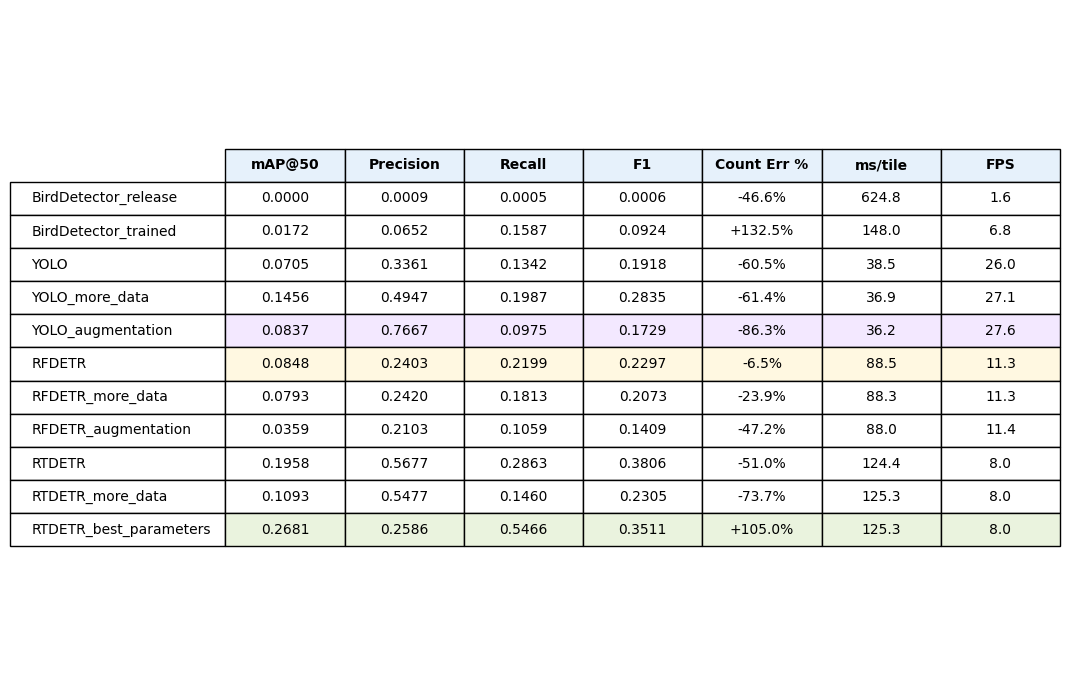

,mAP@50,Precision,Recall,F1,Count Err %,ms/tile,FPS
Model,,,,,,,
BirdDetector_release,0.0000,0.0009,0.0005,0.0006,-46.6%,624.8,1.6
BirdDetector_trained,0.0172,0.0652,0.1587,0.0924,+132.5%,148.0,6.8
YOLO,0.0705,0.3361,0.1342,0.1918,-60.5%,38.5,26.0
YOLO_more_data,0.1456,0.4947,0.1987,0.2835,-61.4%,36.9,27.1
YOLO_augmentation,0.0837,0.7667,0.0975,0.1729,-86.3%,36.2,27.6
RFDETR,0.0848,0.2403,0.2199,0.2297,-6.5%,88.5,11.3
RFDETR_more_data,0.0793,0.2420,0.1813,0.2073,-23.9%,88.3,11.3
RFDETR_augmentation,0.0359,0.2103,0.1059,0.1409,-47.2%,88.0,11.4
RTDETR,0.1958,0.5677,0.2863,0.3806,-51.0%,124.4,8.0


In [7]:
plot_comparison_table(results)

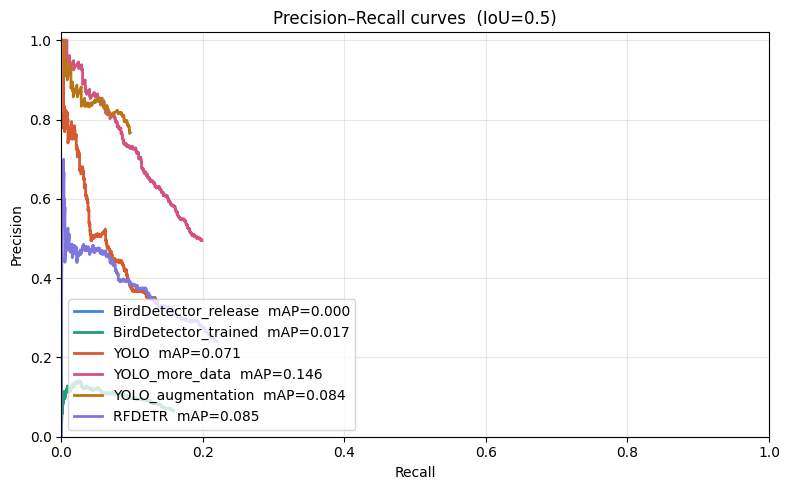

In [8]:
plot_pr_curves(results)

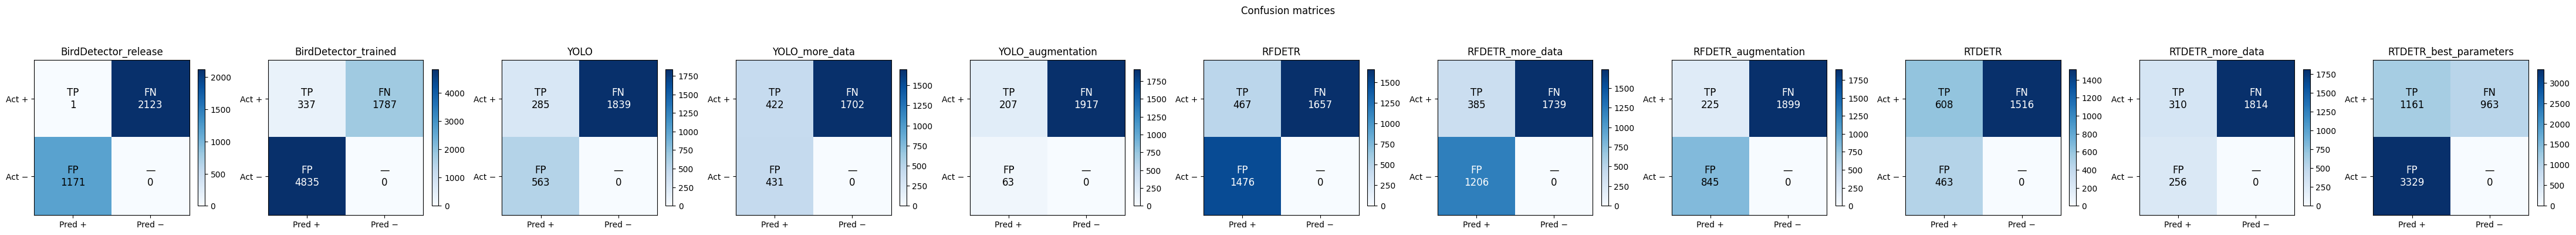

: 

In [ ]:
plot_all_confusion_matrices(results)